# QAOA Postprocessing Analysis

This notebook demonstrates the use of the modular `qaoa_tools` package for comprehensive QAOA analysis including:
- Problem graph generation
- Classical baseline computation
- QAOA training and execution
- Distribution analysis
- Postprocessing with multiple methods
- Visualization and reporting

## 1. Imports and Setup

In [1]:
import os
from pathlib import Path
import datetime

# Import the qaoa_tools package
from qaoa_tools import *

# Import training pipeline (if available)
from qaoa_training_pipeline.training import DepthOneScanTrainer
from qaoa_training_pipeline.evaluation import EfficientDepthOneEvaluator
from qaoa_training_pipeline.utils.graph_utils import graph_to_operator, solve_max_cut

print("✓ Imports successful")

✓ Imports successful


## 2. Configuration

In [2]:
CONFIG = {
    # Backend mode
    "USE_REAL_BACKEND": True,
    "RUN_MODE": "hardware",          # "hardware" or "simulator"
    "BACKEND_NAME": "ibm_marrakesh",
    "SIMULATOR_IDEAL": False,

    # Problem
    "GRAPH_N": 25,
    "GRAPH_D": 4,
    "GRAPH_SEED": 7,

    # QAOA
    "REPS": 1,
    "SEED": 7,
    "SHOTS": 20000,
    "OPTIMIZATION_LEVEL": 1,

    # Classical baseline
    "CLASSICAL_METHOD": "fast_heuristic",
    "HEUR_RESTARTS": 50,
    "HEUR_SWEEPS": 400,

    # SAT mapping + subset selection
    "USE_SAT_MAPPING": True,
    "SAT_TIMEOUT": 10,
    "USE_CUSTOM_FIDELITY_EVALUATOR": True,

    # Plot controls
    "PLOT_TOPK": 40,
    "SAVE_DIR": "qaoa_notebook_runs",
}

# Create output directory
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
OUTDIR = Path(CONFIG["SAVE_DIR"]) / f"run_{timestamp}"
OUTDIR.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {OUTDIR}")

Output directory: qaoa_notebook_runs/run_20260510_134044


## 3. Generate Problem Graph

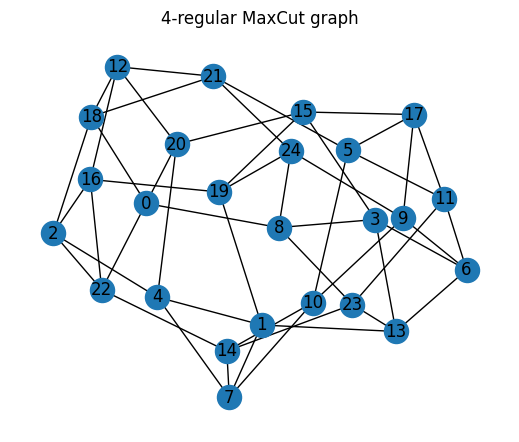

Graph: 25 nodes, 50 edges


In [3]:
graph = generate_d_regular_graph(
    CONFIG["GRAPH_N"], 
    CONFIG["GRAPH_D"], 
    CONFIG["GRAPH_SEED"], 
    auto_fix=True
)

draw_graph(
    graph, 
    title=f"{CONFIG['GRAPH_D']}-regular MaxCut graph",
    outpath=OUTDIR/"plots"/"graph.png", 
    show=True
)

print(f"Graph: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")

## 4. Classical Baseline

In [4]:
# Using training pipeline solver
cost_op = graph_to_operator(graph, pre_factor=-0.5)
print("Cost operator qubits:", cost_op.num_qubits)
print("Edges:", graph.number_of_edges())

max_cut, min_cut, ar = solve_max_cut(cost_op)

# Using qaoa_tools solver
classical_opt, classical_bits = maxcut_exact_ilp(graph)
print(f"Classical best cut: {classical_opt}")
print(f"Classical best bits: {classical_bits}")

Cost operator qubits: 25
Edges: 50
Restricted license - for non-production use only - expires 2027-11-29
Classical best cut: 40.0
Classical best bits: [1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0]


## 5. QAOA Training

In [5]:
trainer = DepthOneScanTrainer(EfficientDepthOneEvaluator())
train_res = trainer.train(cost_op, num_points=60)

beta_train, gamma_train = train_res["optimized_params"]
print(f"Trained (beta, gamma): ({beta_train:.6f}, {gamma_train:.6f})")
print(f"Trainer energy: {train_res['energy']:.6f}")

Trained (beta, gamma): (2.768861, 5.750712)
Trainer energy: 7.502551


## 6. Training Diagnostics

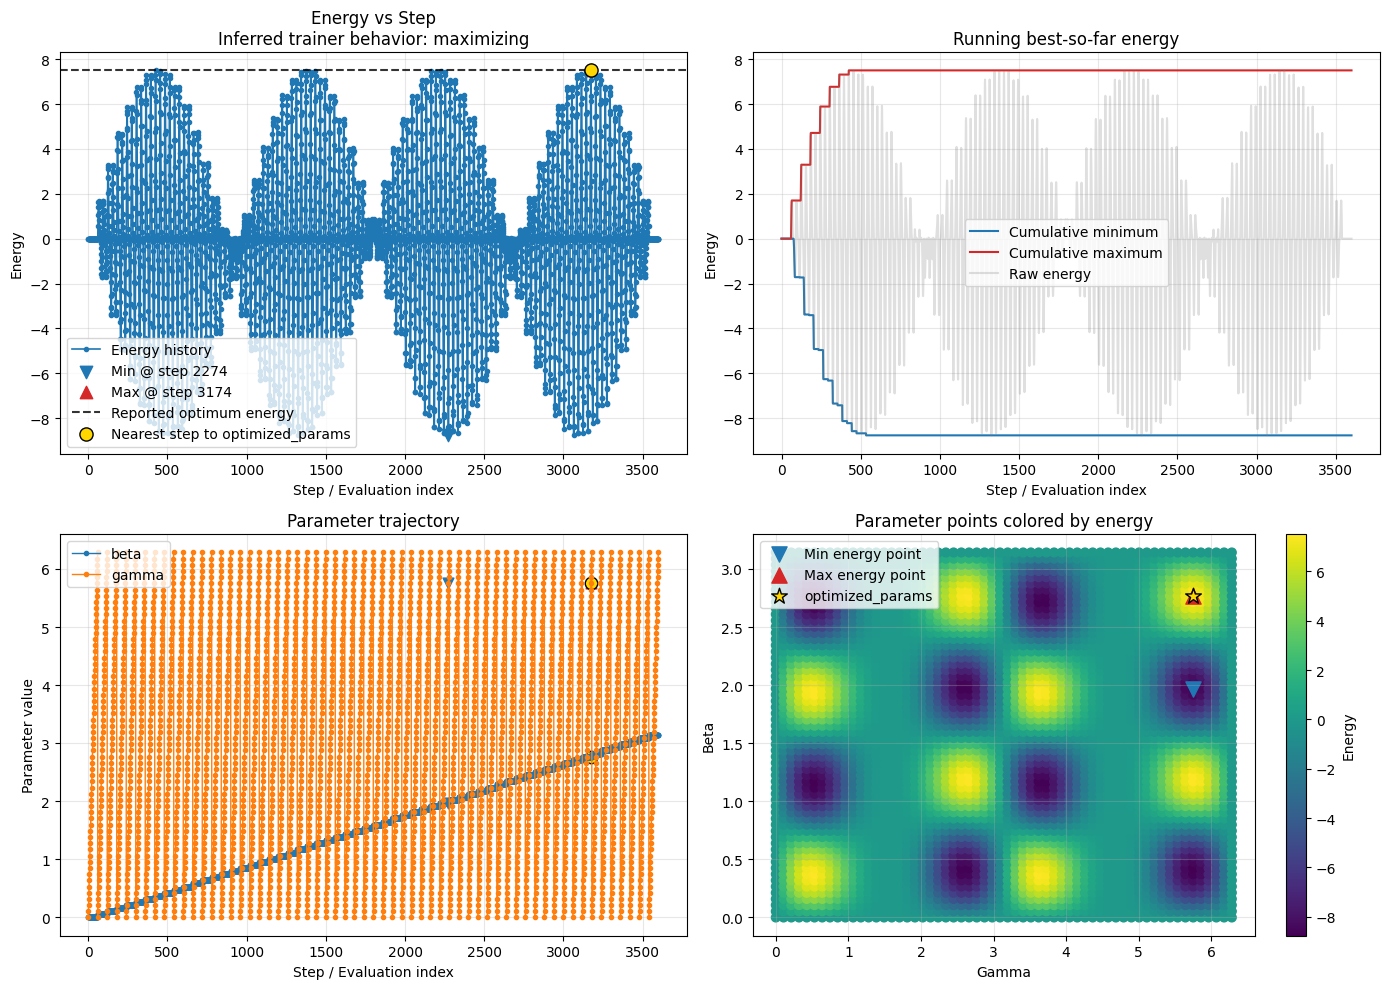

========== Training diagnostic summary ==========
Number of evaluations: 3600
Reported optimized_params (beta, gamma): (2.76886132181, 5.75071197606)
Reported trainer energy: 7.50255072096

Minimum energy in history: -8.76956994882 at step 2274
  params at minimum: beta=1.97015132513, gamma=5.75071197606

Maximum energy in history: 7.50255072096 at step 3174
  params at maximum: beta=2.76886132181, gamma=5.75071197606

Nearest sampled step to optimized_params: step 3174
  sampled params there: beta=2.76886132181, gamma=5.75071197606
  energy there: 7.50255072096

Inferred trainer behavior: maximizing
Inferred mode: maximizing


In [6]:
summary = plot_training_diagnostics(train_res)
print(f"Inferred mode: {summary['inferred_mode']}")

## 7. Backend Setup

In [7]:
real_backend, exec_backend, backend_name = get_backend(CONFIG)
print(f"Backend: {backend_name}")

qiskit_runtime_service._discover_account:WARNING:2026-05-10 13:40:56,914: Loading account with the given token. A saved account will not be used.


Backend: ibm_marrakesh


## 8. SAT Mapping

In [8]:
sat_cost_op, sat_map, sat_dir, min_sat_layers = apply_sat_mapping(cost_op, CONFIG)

[SAT] direction=old_to_new scoreA=0 scoreB=90 min_layers=9


## 9. Qubit Selection

In [9]:
from qopt_best_practices.qubit_selection import BackendEvaluator

path_finder = BackendEvaluator(real_backend)
path, fidelity, num_subsets = path_finder.evaluate(sat_cost_op.num_qubits)

print(f"Best path: {path}")
print(f"Best path fidelity: {fidelity:.6f}")
print(f"Num. evaluated paths: {num_subsets}")

plot_backend_subset(
    real_backend, 
    path, 
    outpath=OUTDIR/"plots"/"backend_subset.png", 
    show=True
)

Best path: [10, 11, 12, 13, 14, 15, 19, 35, 34, 33, 39, 53, 54, 55, 59, 75, 74, 73, 79, 93, 92, 91, 98, 111, 110]
Best path fidelity: 0.958001
Num. evaluated paths: 65877


## 10. Build and Transpile Circuits

In [10]:
circuits = build_bound_executable_circuits(
    sat_cost_op,
    train_res["optimized_qaoa_angles"],
    real_backend,
    CONFIG,
    active_path=path,
)

for name, circ in circuits.items():
    print_metrics(name, circ)
    save_circuit_png(circ, name, OUTDIR / "plots")

[baseline] depth=120 n_2q=362 swap=0 n_1q=1415 delay=0


## 11. Execute Circuits

In [11]:
artifacts, job_id = run_sampler_circuits(
    exec_backend,
    circuits,
    CONFIG,
)

print(f"Job ID: {job_id}")
for k, a in artifacts.items():
    print(f"{k} shots: {sum(a.counts.values())}")

Job ID: d800oulpa59c73b6e9f0
baseline shots: 20000


## 12. Configure Postprocessing

In [12]:
CONFIG["REFERENCE_SELECTION"] = "hybrid"  # "prob", "objective", or "hybrid"

CONFIG["POSTPROCESSORS"] = [
    HighProbGreedy1Flip(),
    MQCStyleMultiQubitCorrection(
        top_m=500,
        max_passes=3,
        reference_mode=CONFIG["REFERENCE_SELECTION"],
    ),
]

postselect_policy = {
    "method": "mass",
    "mass_keep": 0.90,
    "prob_threshold": None,
    "k_max": 2000
}

print("Postprocessors configured:")
for proc in CONFIG["POSTPROCESSORS"]:
    print(f"  - {proc.display_name}")

Postprocessors configured:
  - HighProb + Greedy(1-flip) polish
  - MQC-style multi-qubit correction + polish


## 13. Run Comprehensive Analysis

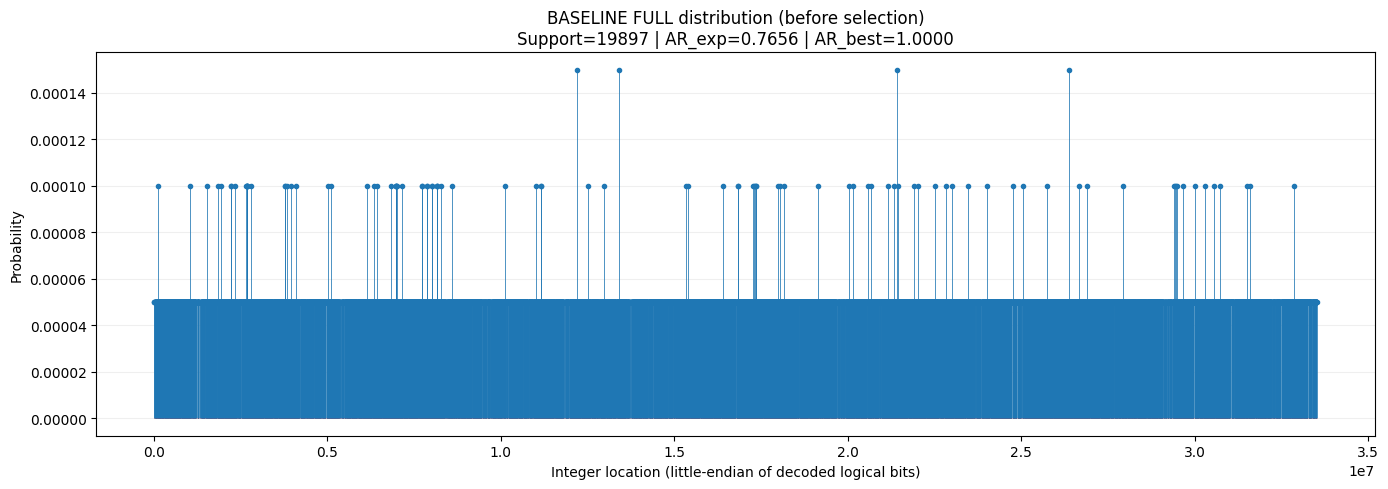

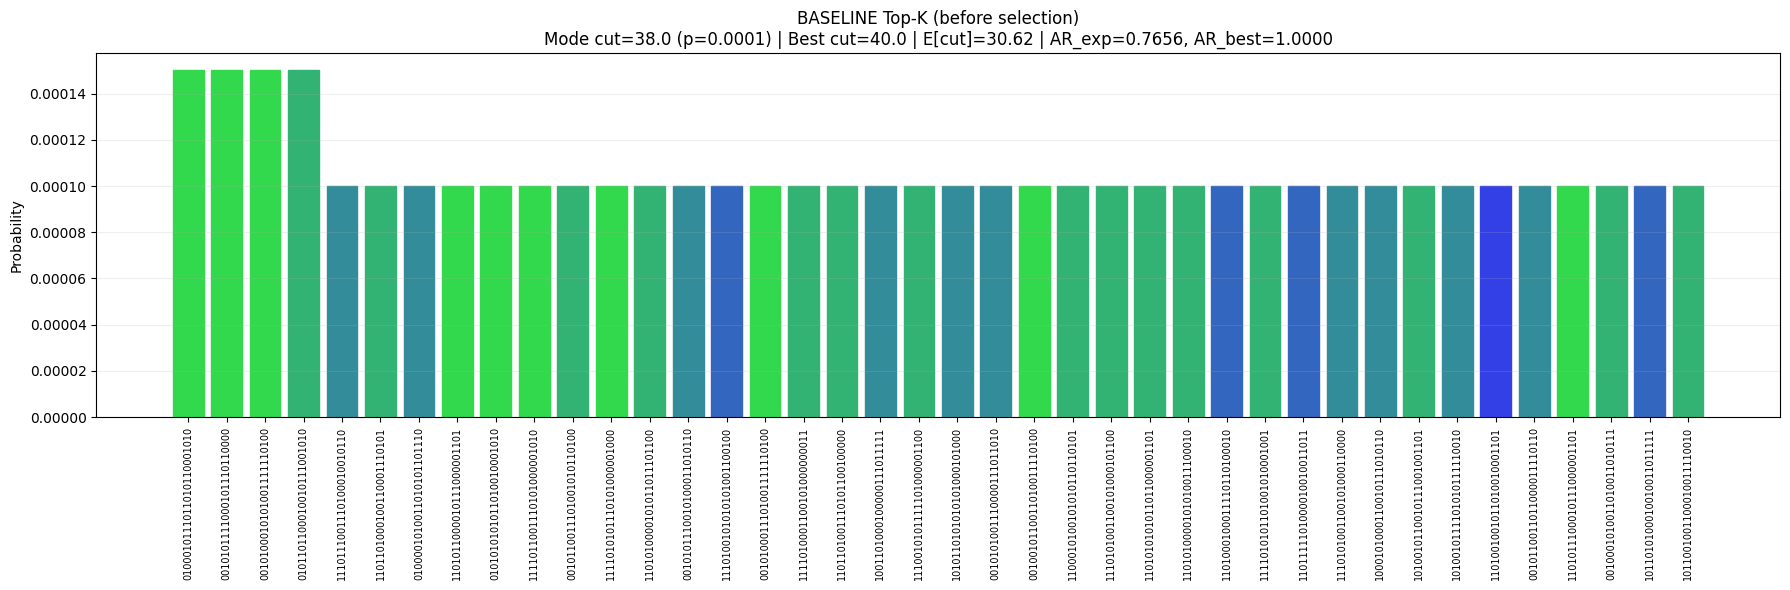


[baseline] Mode cut=38.0 (p=0.000150) vs classical=40.0 | AR_mode=0.9500
[baseline] Best cut=40.0 | AR_best=1.0000 | E[cut]=30.62 | AR_exp=0.7656 | support=19897


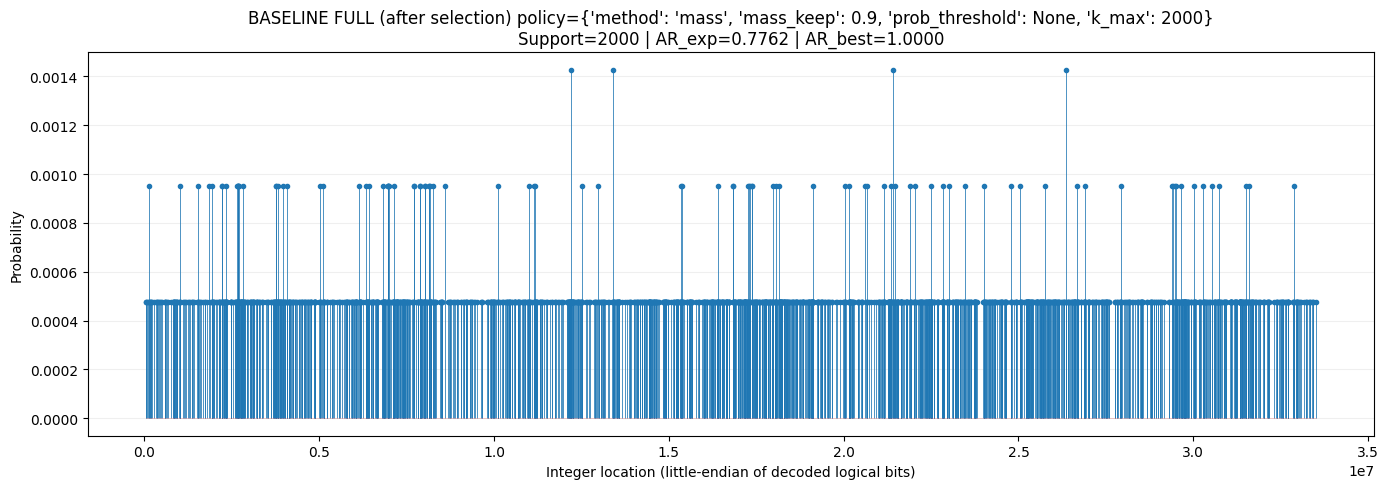

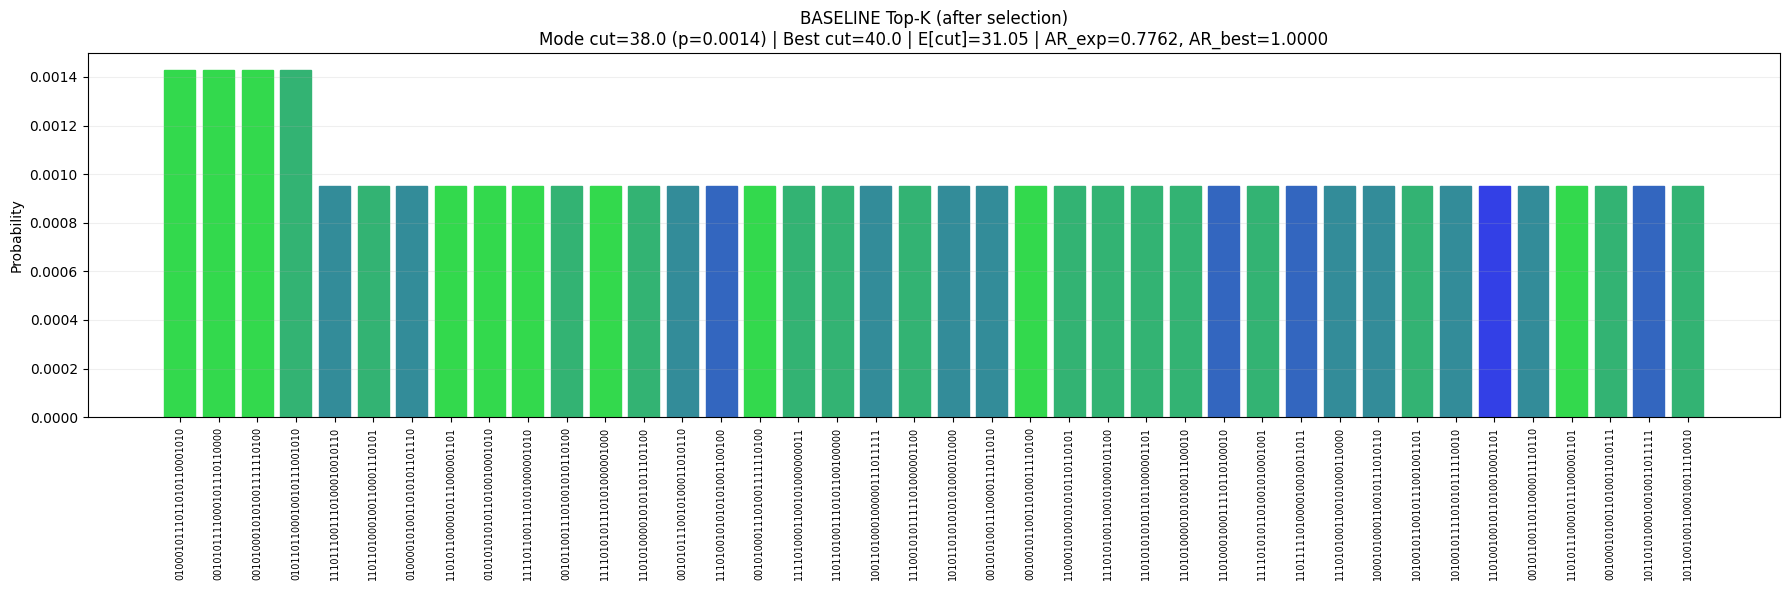

✅ Saved analysis_summary: qaoa_notebook_runs/run_20260510_134044/data/analysis_summary_ibm_marrakesh_hardware_n25_act25_shots20000.json


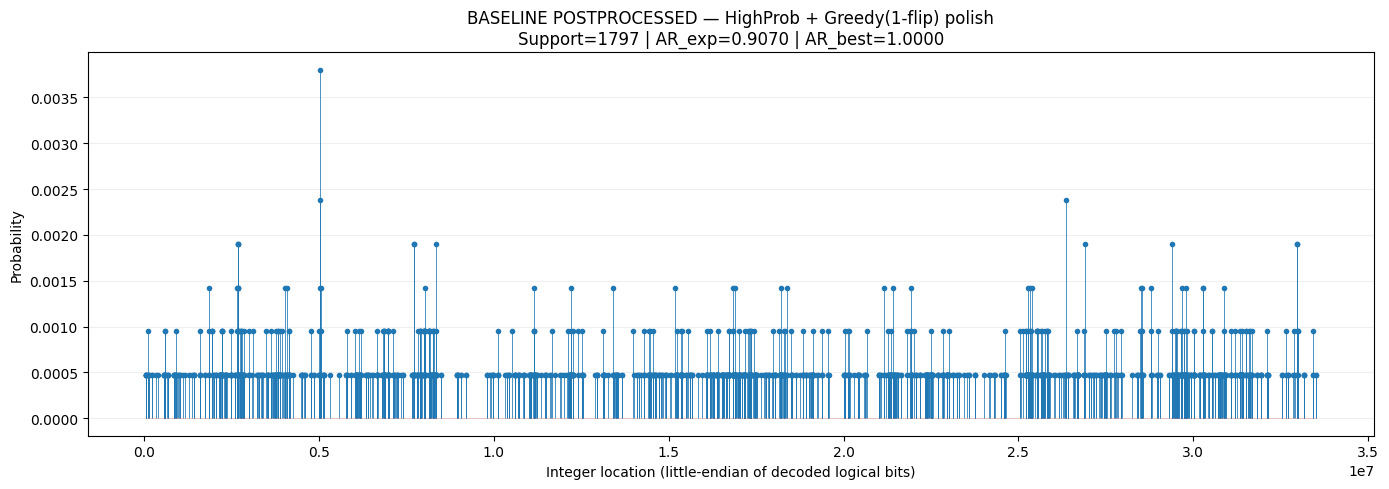

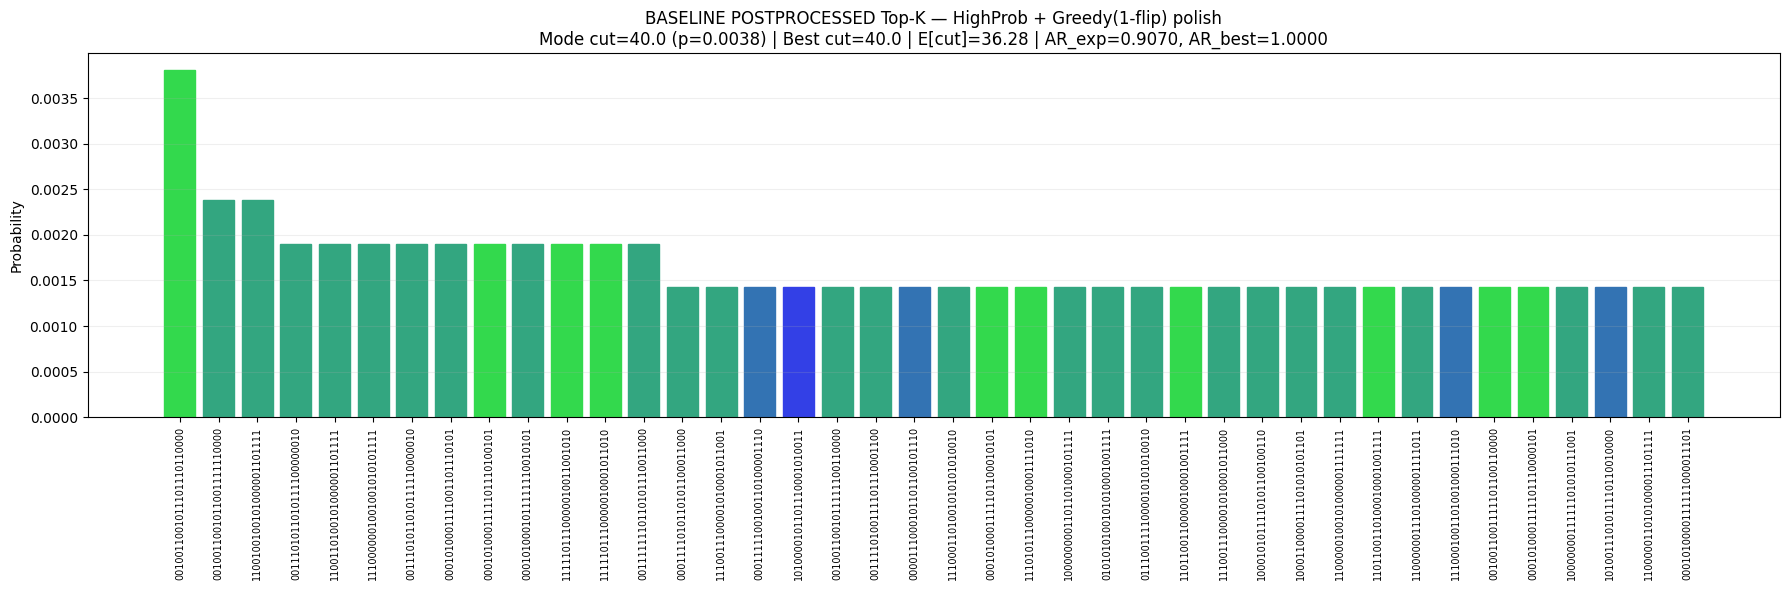

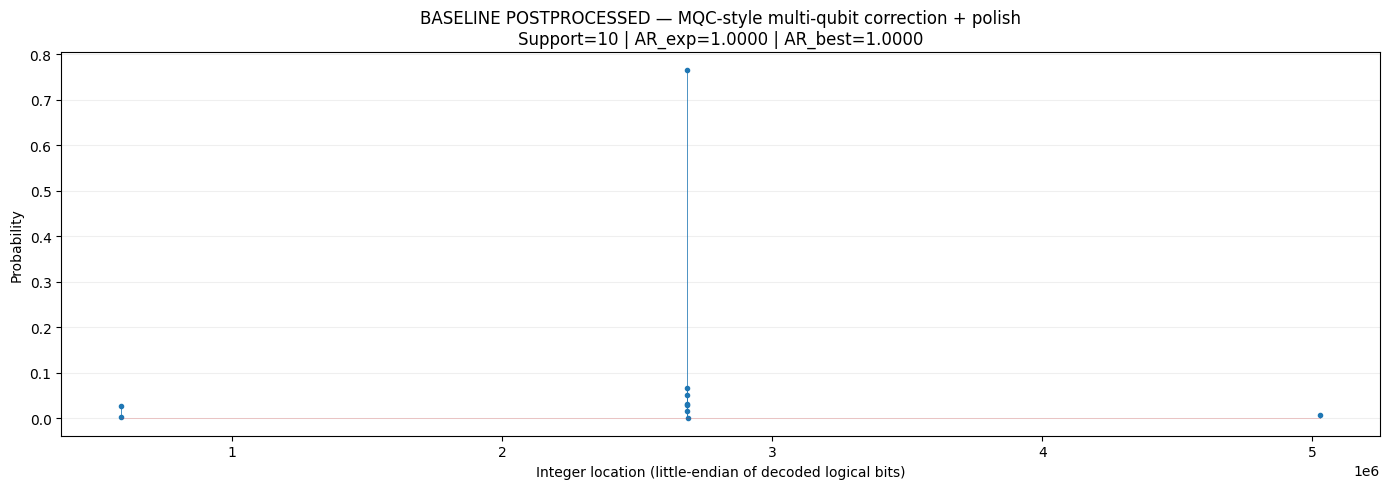

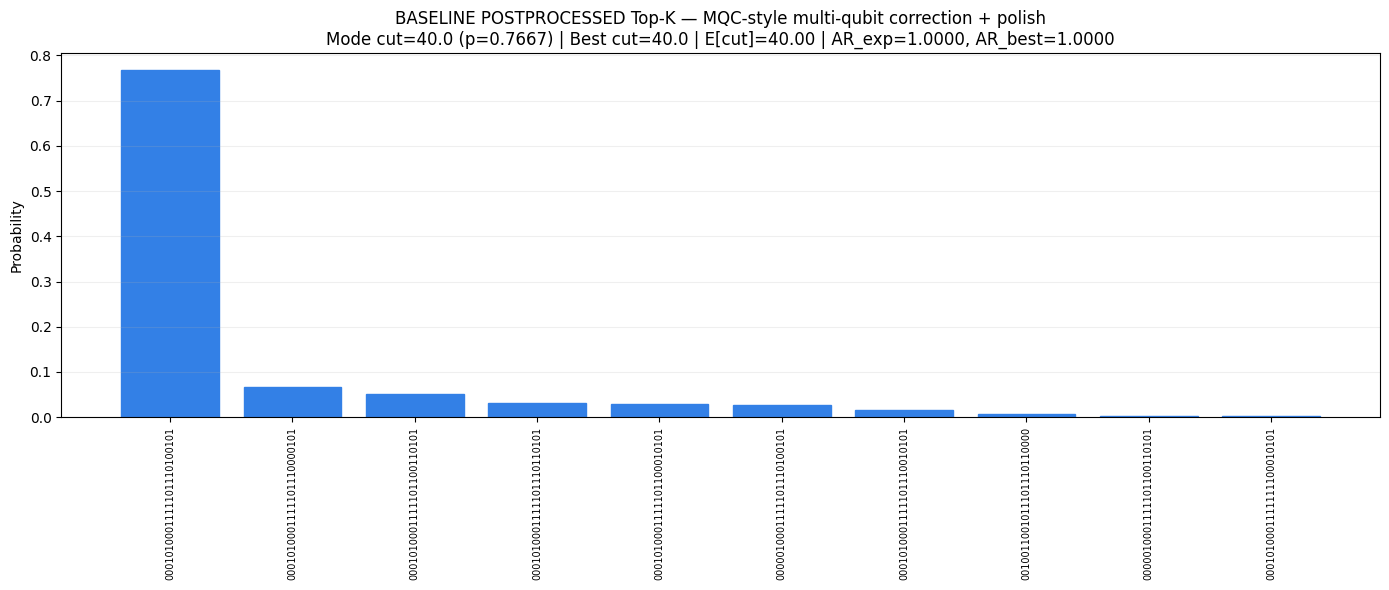

✅ Saved postprocessed_suite: qaoa_notebook_runs/run_20260510_134044/data/postprocessed_suite_ibm_marrakesh_hardware_n25_act25_shots20000.json


In [13]:
report = analyze_and_report(
    outdir=OUTDIR,
    config=CONFIG,
    graph=graph,
    backend_name=backend_name,
    circuits=circuits,
    artifacts=artifacts,
    classical_opt=classical_opt,
    sat_map=sat_map,
    sat_dir=sat_dir,
    postselect=postselect_policy,
    postprocessor=None,
)

## 14. Display Results

In [14]:
print("\n" + "="*60)
print("CIRCUIT METRICS")
print("="*60)
display(report["metrics_df"])


CIRCUIT METRICS


,variant,depth,width,ops,n_1q,n_2q,n_swap,n_delay,n_meas,n_barrier
0,baseline,120,156,"{'sx': 800, 'rz': 589, 'cz': 362, 'x': 26, 'me...",1415,362,0,0,25,1


In [15]:
print("\n" + "="*60)
print("DISTRIBUTION SUMMARIES")
print("="*60)
display(report["summaries_df"])


DISTRIBUTION SUMMARIES


,variant,n,classical_opt,mode_bitstring,mode_prob,mode_cut,best_bitstring,best_prob,best_cut,expected_cut,ar_best,ar_expected,num_support,kept_policy
0,baseline,25,40.0,0100010111011010110001010,0.000150,38.0,1101010101101110010110000,0.000100,40.0,30.622700,1.0,0.765567,19897,None
1,baseline_selected,25,40.0,0100010111011010110001010,0.001427,38.0,1101010101101110010110000,0.000951,40.0,31.047076,1.0,0.776177,2000,"{'mass_raw': 0.10514999999999661, 'method': 'm..."


In [16]:
print("\n" + "="*60)
print("POSTPROCESSING RESULTS")
print("="*60)
if report.get("post_suite_df") is not None and not report["post_suite_df"].empty:
    display(report["post_suite_df"])
else:
    print("No postprocessing suite output found.")


POSTPROCESSING RESULTS


,variant,method,reference,expected_cut,best_cut,ar_expected,ar_best,num_support
0,baseline,HighProb + Greedy(1-flip) polish,Chancellor 2017 (hybrid local search with anne...,36.27865,40.0,0.906966,1.0,1797
1,baseline,MQC-style multi-qubit correction + polish,"Ayanzadeh et al. Sci Rep 11, 16119 (2021)",40.00000,40.0,1.000000,1.0,10


In [17]:
print(f"\n✓ All results saved to: {OUTDIR}")
print("\nGenerated files:")
print(f"  - Plots: {OUTDIR / 'plots'}")
print(f"  - Tables: {OUTDIR / 'tables'}")
print(f"  - Data: {OUTDIR / 'data'}")


✓ All results saved to: qaoa_notebook_runs/run_20260510_134044

Generated files:
  - Plots: qaoa_notebook_runs/run_20260510_134044/plots
  - Tables: qaoa_notebook_runs/run_20260510_134044/tables
  - Data: qaoa_notebook_runs/run_20260510_134044/data
